In [10]:
import pandas as pd
import numpy as np
import textstat
import string
import spacy
import re

import seaborn as sns
import matplotlib.pyplot as plt

import nltk
nltk.download('cmudict')
textstat.set_lang("pt")

[nltk_data] Downloading package cmudict to
[nltk_data]     C:\Users\redga\AppData\Roaming\nltk_data...
[nltk_data]   Package cmudict is already up-to-date!


## (1) Functions and Processing

In [11]:
nlp = spacy.load("pt_core_news_lg", disable=["ner"])

AUXILIARY_VERBS_PT = {
    "ser", "estar", "ter", "haver", "ir"
}

def get_textstat_features(texts):
    features = []
    for x in texts:
        n_sent = max(textstat.sentence_count(x), 1)
        n_words = max(textstat.lexicon_count(x), 1)

        features.append([
            textstat.letter_count(x),
            n_sent,
            textstat.avg_letter_per_word(x),
            n_words / n_sent,
            textstat.avg_syllables_per_word(x),
            textstat.reading_time(x),
        ])
    return np.array(features)

def mean_punctuation_per_word(texts):
    punct = set(string.punctuation)
    results = []

    for txt in texts:
        words = txt.split()
        n_words = len(words)

        if n_words == 0:
            results.append([0.0, 0.0, 0.0])
            continue

        total_punct = sum(1 for ch in txt if ch in punct)
        exclam = txt.count("!")
        quest = txt.count("?")
        
        results.append([
            total_punct / n_words,
            exclam / n_words,
            quest / n_words
        ])
    return np.array(results)

def mean_verbs_per_word(texts):
    feats = []
    for doc in nlp.pipe(texts, batch_size=256, disable=["ner", "lemmatizer", "parser"]):
        words = [t for t in doc if t.is_alpha]
        if len(words) == 0:
            feats.append(0.0)
            continue
        verb_count = sum(1 for t in words if t.pos_ == "VERB")
        feats.append(verb_count / len(words))
    return np.array(feats).reshape(-1, 1)

def mean_auxiliaries_per_word(texts):
    results = []
    for doc in nlp.pipe(texts, batch_size=256, disable=["ner", "parser"]):
        tokens = [tok for tok in doc if tok.is_alpha]
        if len(tokens) == 0:
            results.append(0.0)
            continue

        aux_count = sum(1 for tok in tokens if tok.lemma_.lower() in AUXILIARY_VERBS_PT)
        results.append(aux_count / len(tokens))
    return results

def mean_auxiliaries_per_sentence(texts):
    results = []
    for doc in nlp.pipe(texts, batch_size=256, disable=["ner"]):
        n_sent = len(list(doc.sents))
        if n_sent == 0:
            results.append(0.0)
            continue

        tokens = [tok for tok in doc if tok.is_alpha]

        aux_count = sum(
            1 for tok in tokens
            if tok.lemma_.lower() in AUXILIARY_VERBS_PT
        )

        results.append(aux_count / n_sent)
    return np.array(results)

def flesch_portuguese(texts):
    scores = []
    for t in texts:
        text = str(t).strip()

        num_sent = textstat.sentence_count(text)
        num_words = len(text.split())
        num_syll = textstat.syllable_count(text)

        if num_sent == 0 or num_words == 0:
            scores.append(0.0)
            continue

        flesch_pt = 226 - 1.04 * (num_words / num_sent) - 72 * (num_syll / num_words)
        scores.append(flesch_pt)

    return scores

def uppercase_percentage(texts):
    results = []

    for txt in texts:
        letters = [ch for ch in txt if ch.isalpha()]
        if len(letters) == 0:
            results.append(0.0)
            continue

        upper = sum(1 for ch in letters if ch.isupper())
        results.append(upper / len(letters))

    return np.array(results).reshape(-1, 1)

def mean_unique_word_length(texts):
    results = []

    for txt in texts:
        words = [w.lower() for w in txt.split() if w.isalpha()]
        unique_words = set(words)

        if len(unique_words) == 0:
            results.append(0.0)
            continue

        mean_len = np.mean([len(w) for w in unique_words])
        results.append(mean_len)

    return np.array(results).reshape(-1, 1)

def mean_char_repetition_per_word(texts):
    results = []
    pattern = re.compile(r"(.)\1{2,}")  # 3+ repetições

    for txt in texts:
        words = txt.split()
        if len(words) == 0:
            results.append(0.0)
            continue

        repeated_words = sum(
            1 for w in words if pattern.search(w.lower())
        )

        results.append(repeated_words / len(words))

    return np.array(results).reshape(-1, 1)

## (2) Features for TweetEmotionsPTBR

In [43]:
df = pd.read_csv("../data/treated/tweet_emotions_ptbr_treated.csv")

df['UNCLEAN_TEXT'] = (
    df['UNCLEAN_TEXT']
    .fillna("")        # remove NaN
    .astype(str)       # garante string
)

print(df.shape)
df.head(3)

(12419, 7)


,texto,EMOTION,UNCLEAN_TEXT,BASE_TEXT,TEXT_NO_STOP,TEXT_LEMMA,CLEAN_TEXT
0,͏ ͏ ͏ ͏ ͏ ͏ ͏ ͏\nque júbilo incalculável ver t...,alegria,͏ ͏ ͏ ͏ ͏ ͏ ͏ ͏\nque júbilo incalculável ver t...,que jubilo incalculavel ver todos meus querido...,jubilo incalculavel queridos prestaram ano pas...,que jubilo incalculavel ver todo meu querido q...,jubilo incalculavel querido prestar ano passad...
1,". 𝘀𝗮𝗽𝗼𝗻𝘁𝗮𝗺𝗲𝗻𝘁𝗼𝗶\nSenhor, arranca do meu coraçã...",decepção,". 𝘀𝗮𝗽𝗼𝗻𝘁𝗮𝗺𝗲𝗻𝘁𝗼𝗶\nSenhor, arranca do meu coraçã...",sapontamentoi senhor arranca meu coracao qualq...,sapontamentoi senhor arranca coracao desaponta...,sapontamentoir senhor arrancar meu coracao qua...,sapontamentoir senhor arrancar coracao desapon...
2,"A franquia continua ativa, com o desenvolvimen...",decepção,"A franquia continua ativa, com o desenvolvimen...",franquia continua ativa com desenvolvimento jo...,franquia continua ativa desenvolvimento jogo p...,franquia continuar ativo com desenvolvimento j...,franquia continuar ativo desenvolvimento jogo ...


In [44]:
unclean_text_col = 'UNCLEAN_TEXT'

textstat_feats = get_textstat_features(df[unclean_text_col].tolist()) 

textstat_cols = [
    "letter_count",
    "sentence_count",
    "avg_letter_per_word",
    "words_per_sentence",
    "avg_syllables_per_word",
    "reading_time",
    "fernandez_huerta",
    "szigriszt_pazos",
    "gutierrez_polini"
]

df_textstat = pd.DataFrame(textstat_feats, columns=textstat_cols) 
df = pd.concat([df.reset_index(drop=True), df_textstat.reset_index(drop=True)], axis=1)

punct_feats = mean_punctuation_per_word(df[unclean_text_col].tolist())

punct_cols = [
    "punctuation_per_word",
    "exclamation_per_word",
    "question_per_word"
]

df_punct = pd.DataFrame(punct_feats, columns=punct_cols)

df = pd.concat([df.reset_index(drop=True), df_punct], axis=1)

df["mean_verbs_per_word"] = mean_verbs_per_word(df[unclean_text_col])

df["mean_auxiliaries_per_word"] = mean_auxiliaries_per_word(df[unclean_text_col].tolist())
df["mean_auxiliaries_per_sentence"] = mean_auxiliaries_per_sentence(df[unclean_text_col].tolist())

df["flesch_portuguese"] = flesch_portuguese(df[unclean_text_col].tolist())

df["uppercase_percentage"] = uppercase_percentage(df[unclean_text_col].tolist())
df["mean_unique_word_length"] = mean_unique_word_length(df[unclean_text_col].tolist())
df["mean_char_repetition_per_word"] = mean_char_repetition_per_word(df[unclean_text_col].tolist())

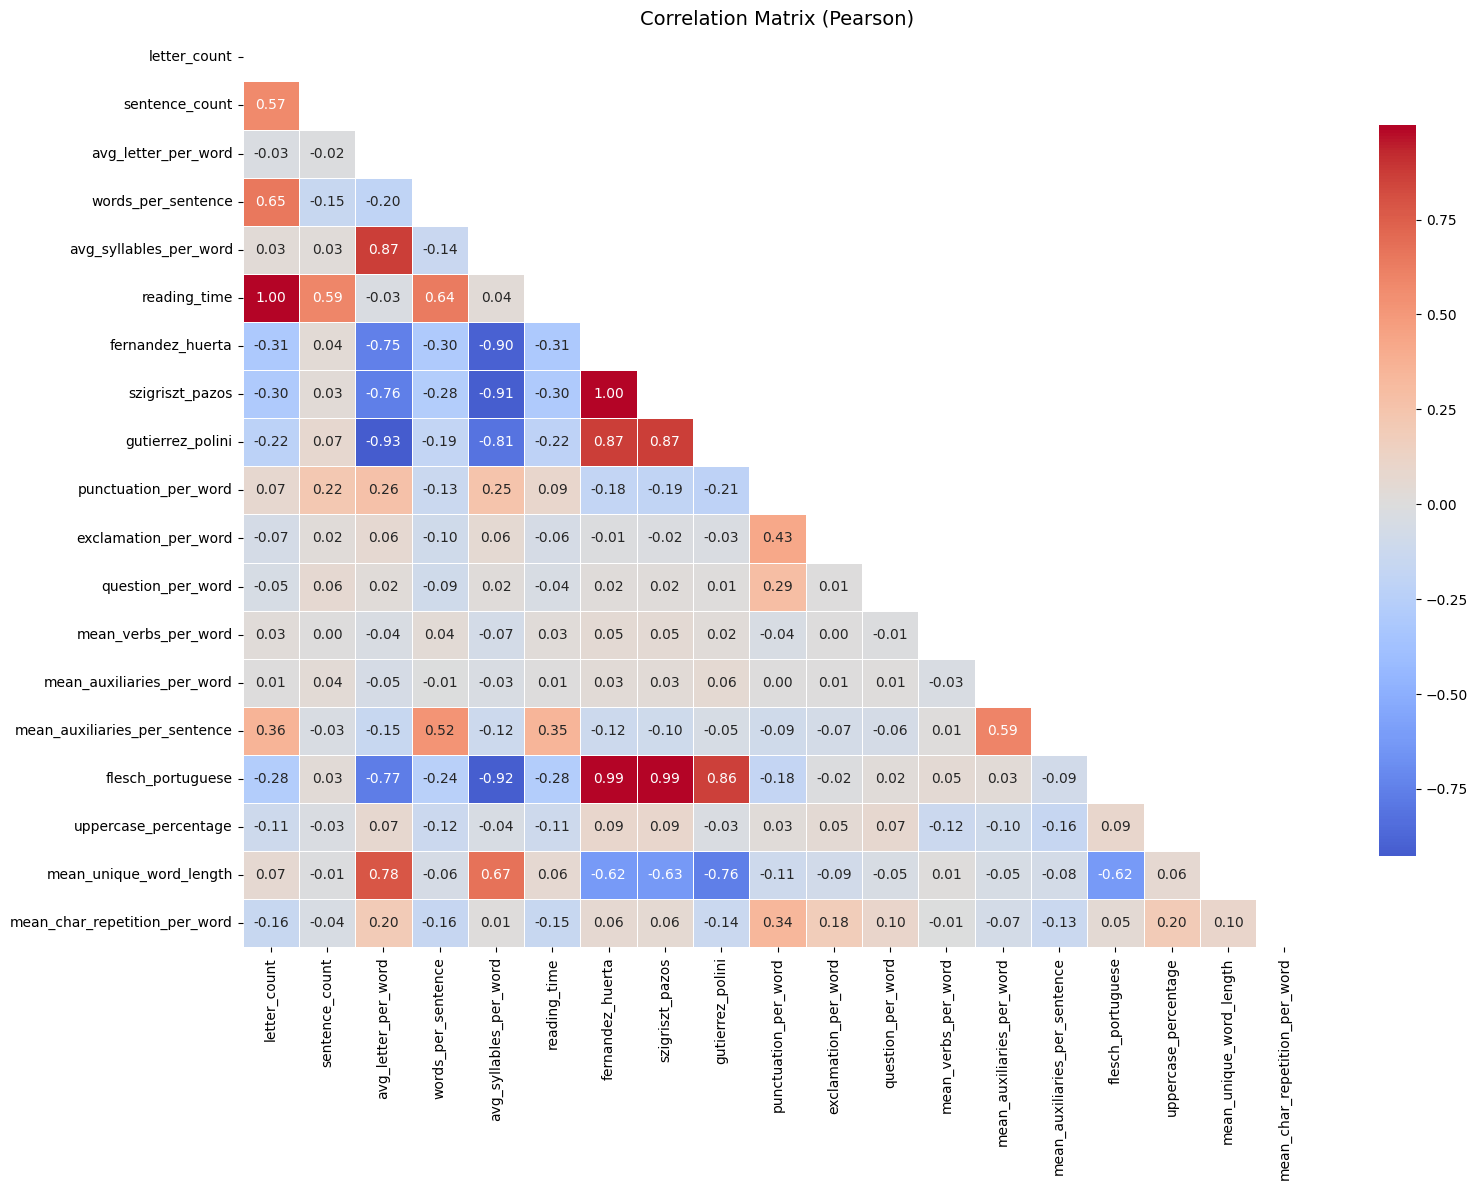

In [45]:
num_cols = df.select_dtypes(include="number")
corr = num_cols.corr(method="pearson")

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix (Pearson)", fontsize=14)
plt.tight_layout()
plt.show()

In [46]:
base_cols = ["UNCLEAN_TEXT", "EMOTION", "BASE_TEXT"]
remove_cols = ['TEXT_NO_STOP', 'CLEAN_TEXT', 'TEXT_LEMMA', 'texto', 'reading_time', 'gutierrez_polini', 'avg_syllables_per_word', 'fernandez_huerta', 'szigriszt_pazos']

feature_cols = [c for c in df.columns if c not in base_cols and c not in remove_cols]

df_final = df[base_cols + feature_cols]

df_final.to_csv(
    "../data/feat/tweet_emotions_ptbr_with_features.csv",
    index=False
)

In [47]:
print(df_final.shape)
print(df_final.isna().sum().sort_values(ascending=False).head(5))

(12419, 17)
UNCLEAN_TEXT      0
EMOTION           0
BASE_TEXT         0
letter_count      0
sentence_count    0
dtype: int64


In [48]:
df_final.describe().T

,count,mean,std,min,25%,50%,75%,max
letter_count,12419.0,93.207021,64.808588,4.000000,40.000000,73.000000,138.000000,253.000000
sentence_count,12419.0,1.480796,0.903465,1.000000,1.000000,1.000000,2.000000,8.000000
avg_letter_per_word,12419.0,4.605407,0.989092,1.666667,4.066667,4.460000,4.960000,37.000000
words_per_sentence,12419.0,14.964744,10.498853,1.000000,8.000000,12.000000,19.000000,60.000000
punctuation_per_word,12419.0,0.121554,0.171617,0.000000,0.000000,0.088235,0.166667,4.000000
exclamation_per_word,12419.0,0.011395,0.074688,0.000000,0.000000,0.000000,0.000000,3.000000
question_per_word,12419.0,0.008356,0.050397,0.000000,0.000000,0.000000,0.000000,2.666667
mean_verbs_per_word,12419.0,0.154310,0.098410,0.000000,0.096774,0.153846,0.205882,1.000000
mean_auxiliaries_per_word,12419.0,0.064469,0.069692,0.000000,0.000000,0.055556,0.100000,0.500000
mean_auxiliaries_per_sentence,12419.0,0.830826,0.983469,0.000000,0.000000,0.600000,1.000000,10.000000


In [49]:
df_final.columns

Index(['UNCLEAN_TEXT', 'EMOTION', 'BASE_TEXT', 'letter_count',
       'sentence_count', 'avg_letter_per_word', 'words_per_sentence',
       'punctuation_per_word', 'exclamation_per_word', 'question_per_word',
       'mean_verbs_per_word', 'mean_auxiliaries_per_word',
       'mean_auxiliaries_per_sentence', 'flesch_portuguese',
       'uppercase_percentage', 'mean_unique_word_length',
       'mean_char_repetition_per_word'],
      dtype='object')

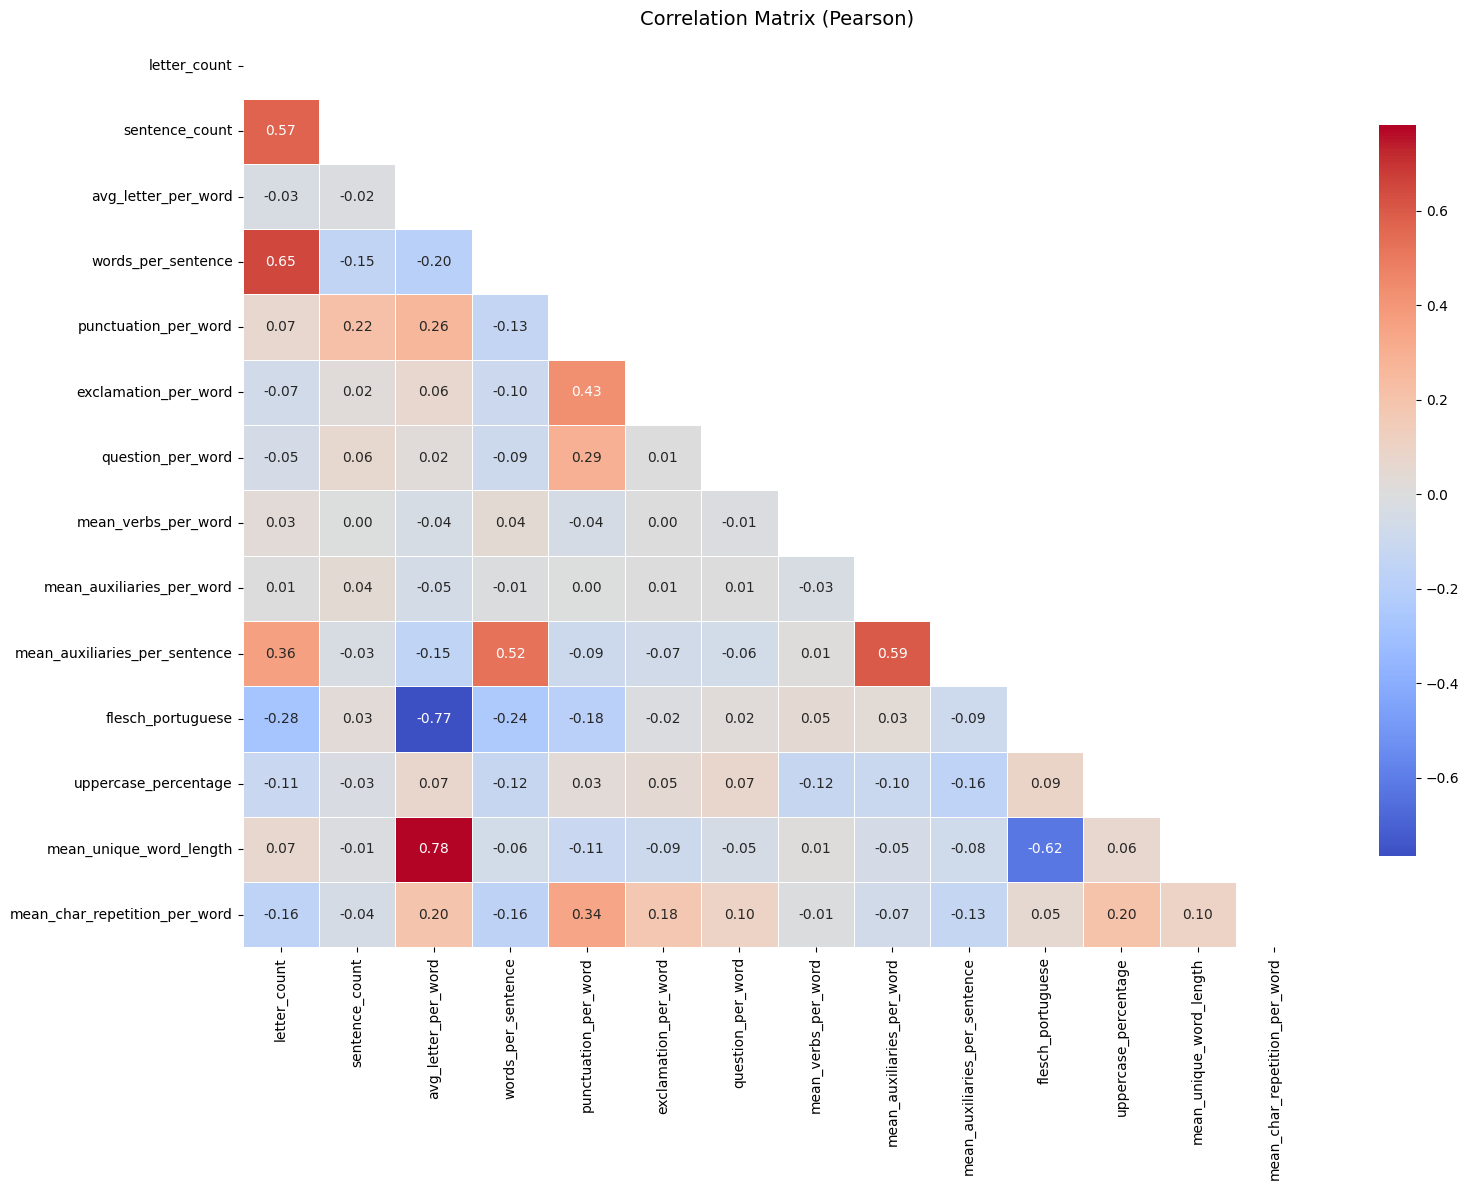

In [50]:
num_cols = df_final.select_dtypes(include="number")
corr = num_cols.corr(method="pearson")

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix (Pearson)", fontsize=14)
plt.tight_layout()
plt.show()

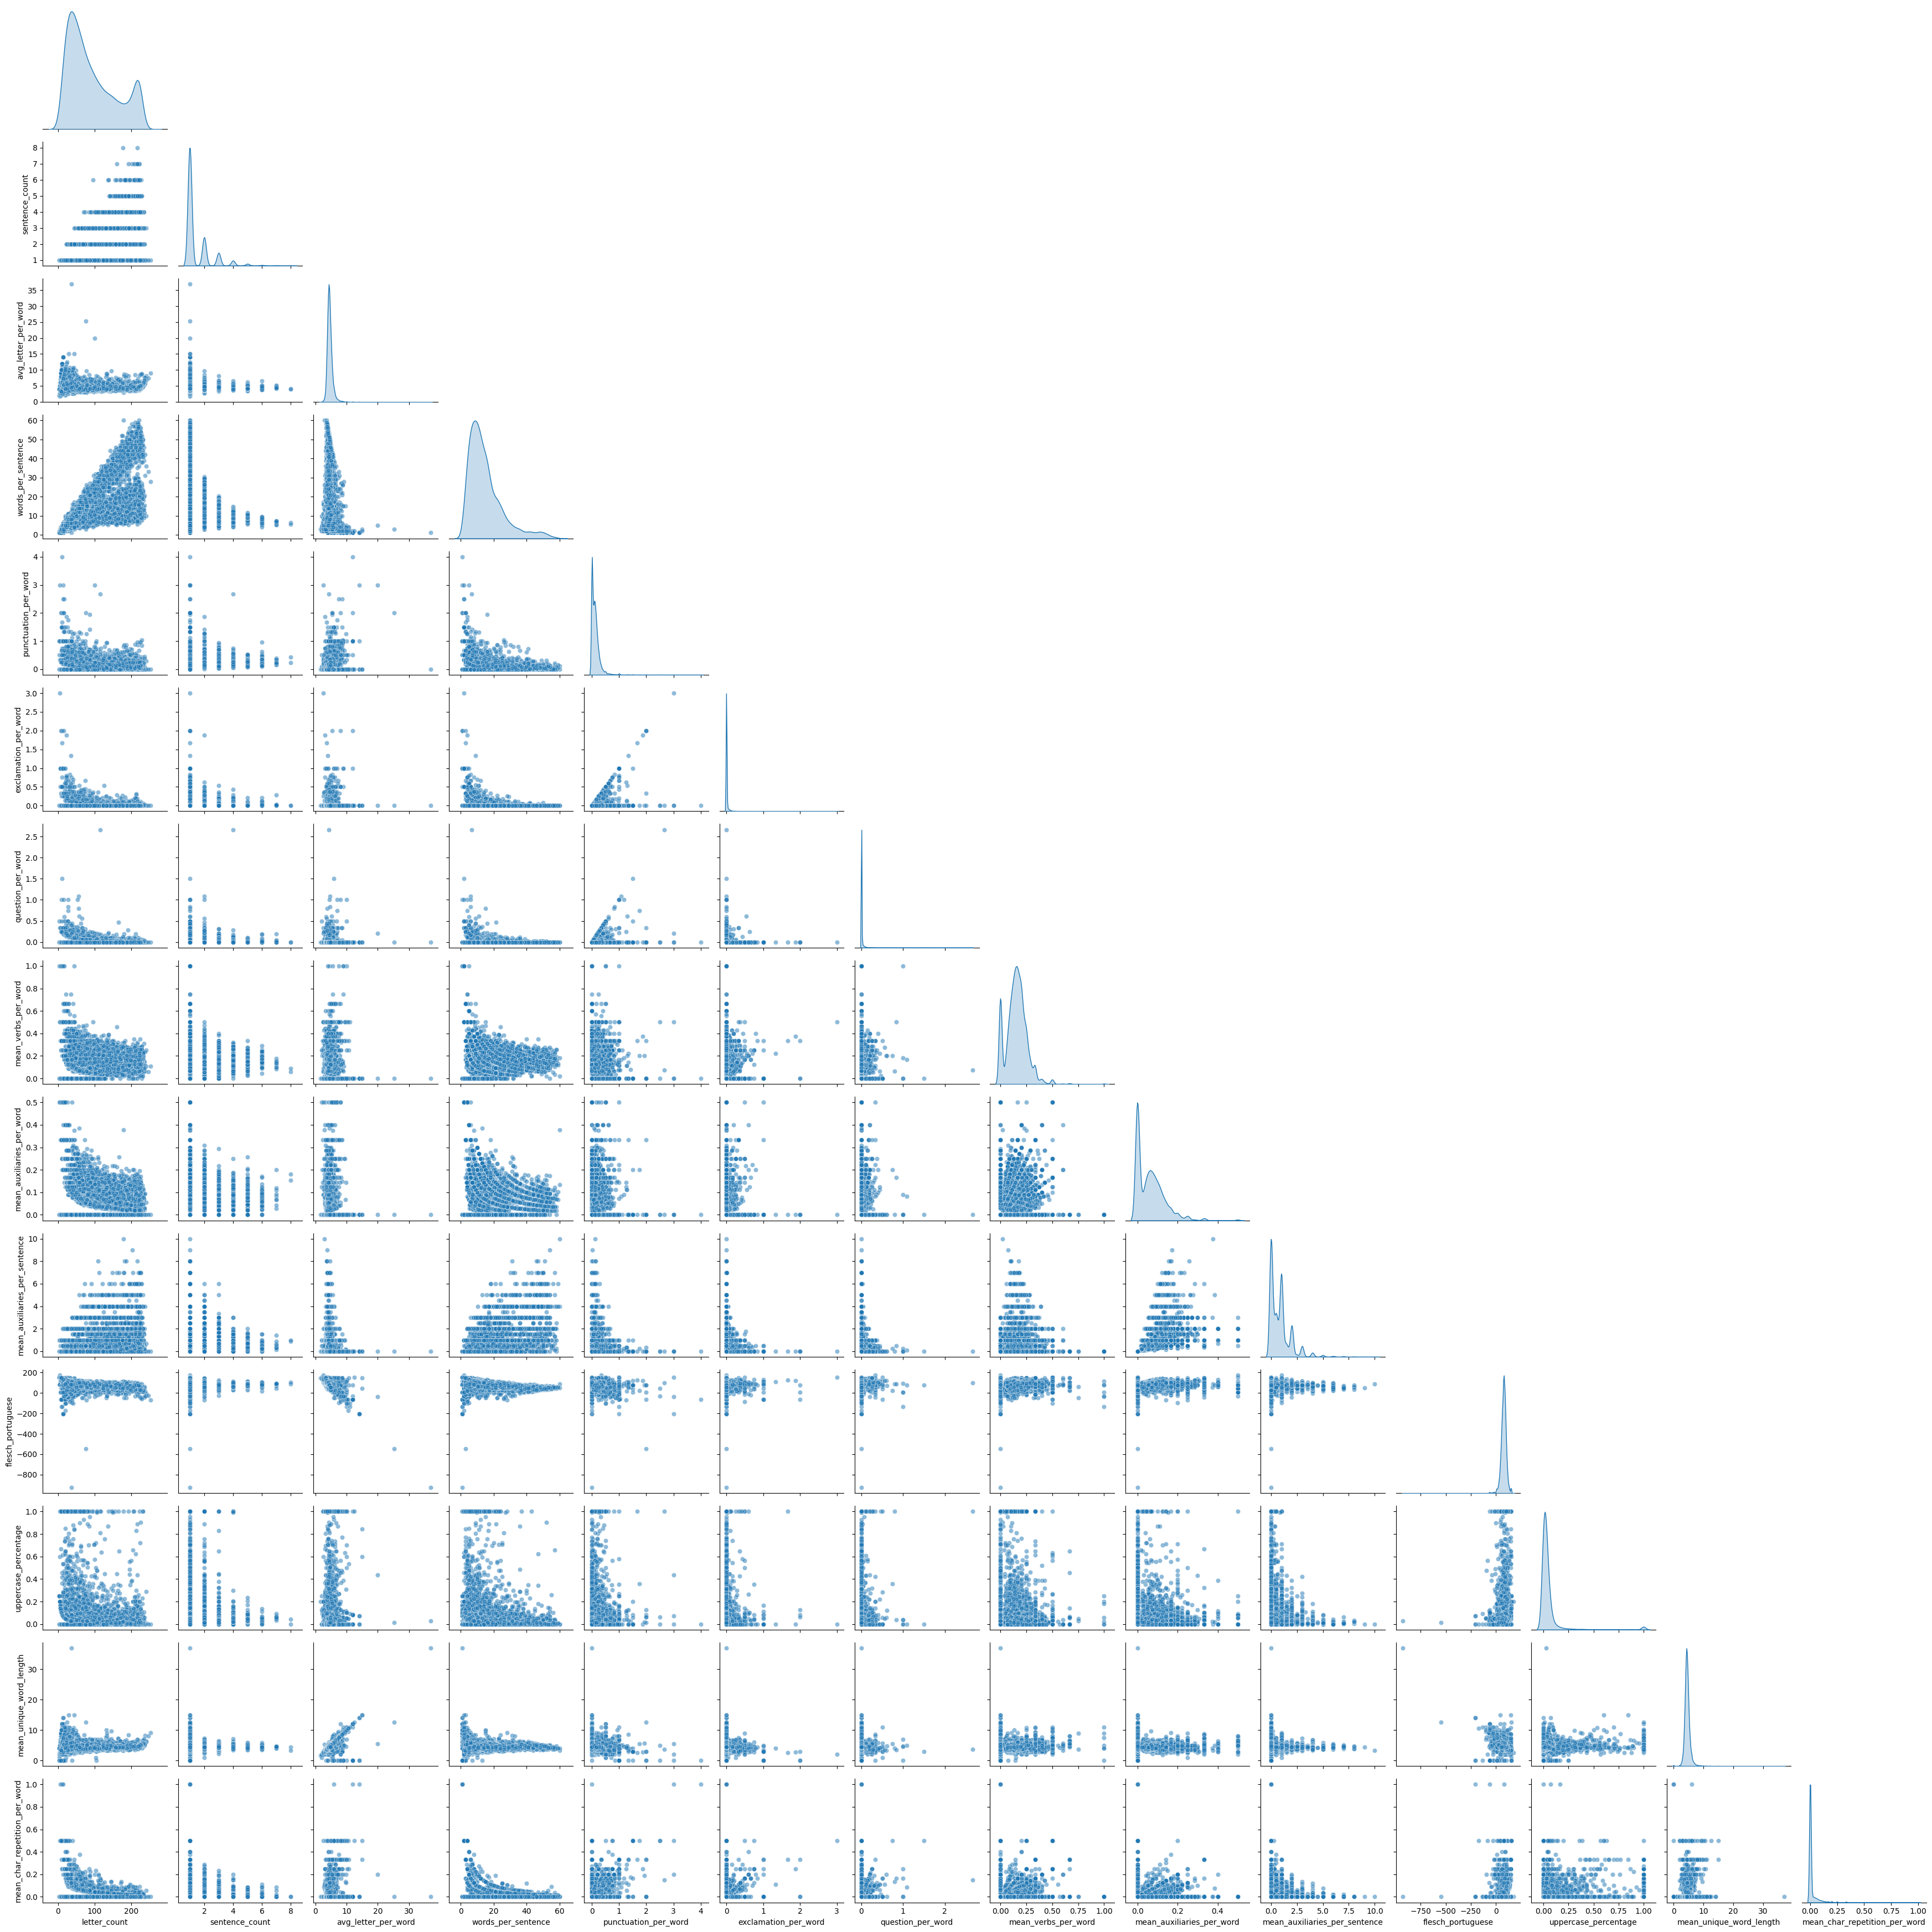

In [51]:
sns.pairplot(
    num_cols,
    corner=True,
    diag_kind="kde",
    plot_kws={"alpha": 0.5},
    diag_kws={"fill": True}
)
plt.tight_layout()
plt.show()

## (3) Features for GoEmotions

In [12]:
df = pd.read_csv("../data/treated/go_emotions_treated.csv")

df['UNCLEAN_TEXT_PT'] = (
    df['UNCLEAN_TEXT_PT']
    .fillna("")        # remove NaN
    .astype(str)       # garante string
)

print(df.shape)
df.head(3)

(54234, 41)


,id,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,UNCLEAN_TEXT_PT,BASE_TEXT_PT,TEXT_NO_STOP_PT,TEXT_LEMMA_PT,CLEAN_TEXT_PT,UNCLEAN_TEXT_EN,BASE_TEXT_EN,TEXT_NO_STOP_EN,TEXT_LEMMA_EN,CLEAN_TEXT_EN
0,eczazk6,0,0,0,0,1,0,0,0,0,...,Tão rápido quanto [NOME] me carregará. Seriame...,tao rapido quanto nome carregara seriamente up...,tao rapido nome carregara seriamente uptown ce...,tao rapido quanto nome carregar seriamente upt...,tao rapido nome carregar seriamente uptown cen...,Fast as [NAME] will carry me. Seriously uptown...,fast name will carry seriously uptown downtown...,fast name will carry seriously uptown downtown...,fast name will carry seriously uptown downtown...,fast name will carry seriously uptown downtown...
1,eczb07q,0,0,0,0,0,0,0,0,0,...,Você estragou isso. Eles tocaram você como um ...,voce estragou isso eles tocaram voce como violino,voce estragou tocaram voce violino,voce estragar isso eles tocar voce como violino,voce estragar tocar voce violino,You blew it. They played you like a fiddle.,you blew they played you like fiddle,you blew they played you like fiddle,you blew they played you like fiddle,you blew they played you like fiddle
2,eczb4bm,0,0,0,0,0,0,0,0,0,...,TL;DR Não há mais Super Bowls para [NAME]. Pre...,nao mais super bowls para name prepare-se para...,nao super bowls name prepare-se temporada vito...,nao mais super bowl para name preparar se para...,nao super bowl name preparar se temporada vito...,TL;DR No more Superbowls for [NAME]. Get ready...,more superbowls for name get ready for another...,more superbowls name get ready another winning...,more superbowls ser name get ready ser another...,more superbowls name get ready another winning...


In [14]:
unclean_text_col = 'UNCLEAN_TEXT_PT'

textstat_feats = get_textstat_features(df[unclean_text_col].tolist()) 

textstat_cols = [
    "letter_count",
    "sentence_count",
    "avg_letter_per_word",
    "words_per_sentence",
    "avg_syllables_per_word",
    "reading_time",
]

df_textstat = pd.DataFrame(textstat_feats, columns=textstat_cols) 
df = pd.concat([df.reset_index(drop=True), df_textstat.reset_index(drop=True)], axis=1)

punct_feats = mean_punctuation_per_word(df[unclean_text_col].tolist())

punct_cols = [
    "punctuation_per_word",
    "exclamation_per_word",
    "question_per_word"
]

df_punct = pd.DataFrame(punct_feats, columns=punct_cols)

df = pd.concat([df.reset_index(drop=True), df_punct], axis=1)

df["mean_verbs_per_word"] = mean_verbs_per_word(df[unclean_text_col])

df["mean_auxiliaries_per_word"] = mean_auxiliaries_per_word(df[unclean_text_col].tolist())
df["mean_auxiliaries_per_sentence"] = mean_auxiliaries_per_sentence(df[unclean_text_col].tolist())

df["flesch_portuguese"] = flesch_portuguese(df[unclean_text_col].tolist())

df["uppercase_percentage"] = uppercase_percentage(df[unclean_text_col].tolist())
df["mean_unique_word_length"] = mean_unique_word_length(df[unclean_text_col].tolist())
df["mean_char_repetition_per_word"] = mean_char_repetition_per_word(df[unclean_text_col].tolist())

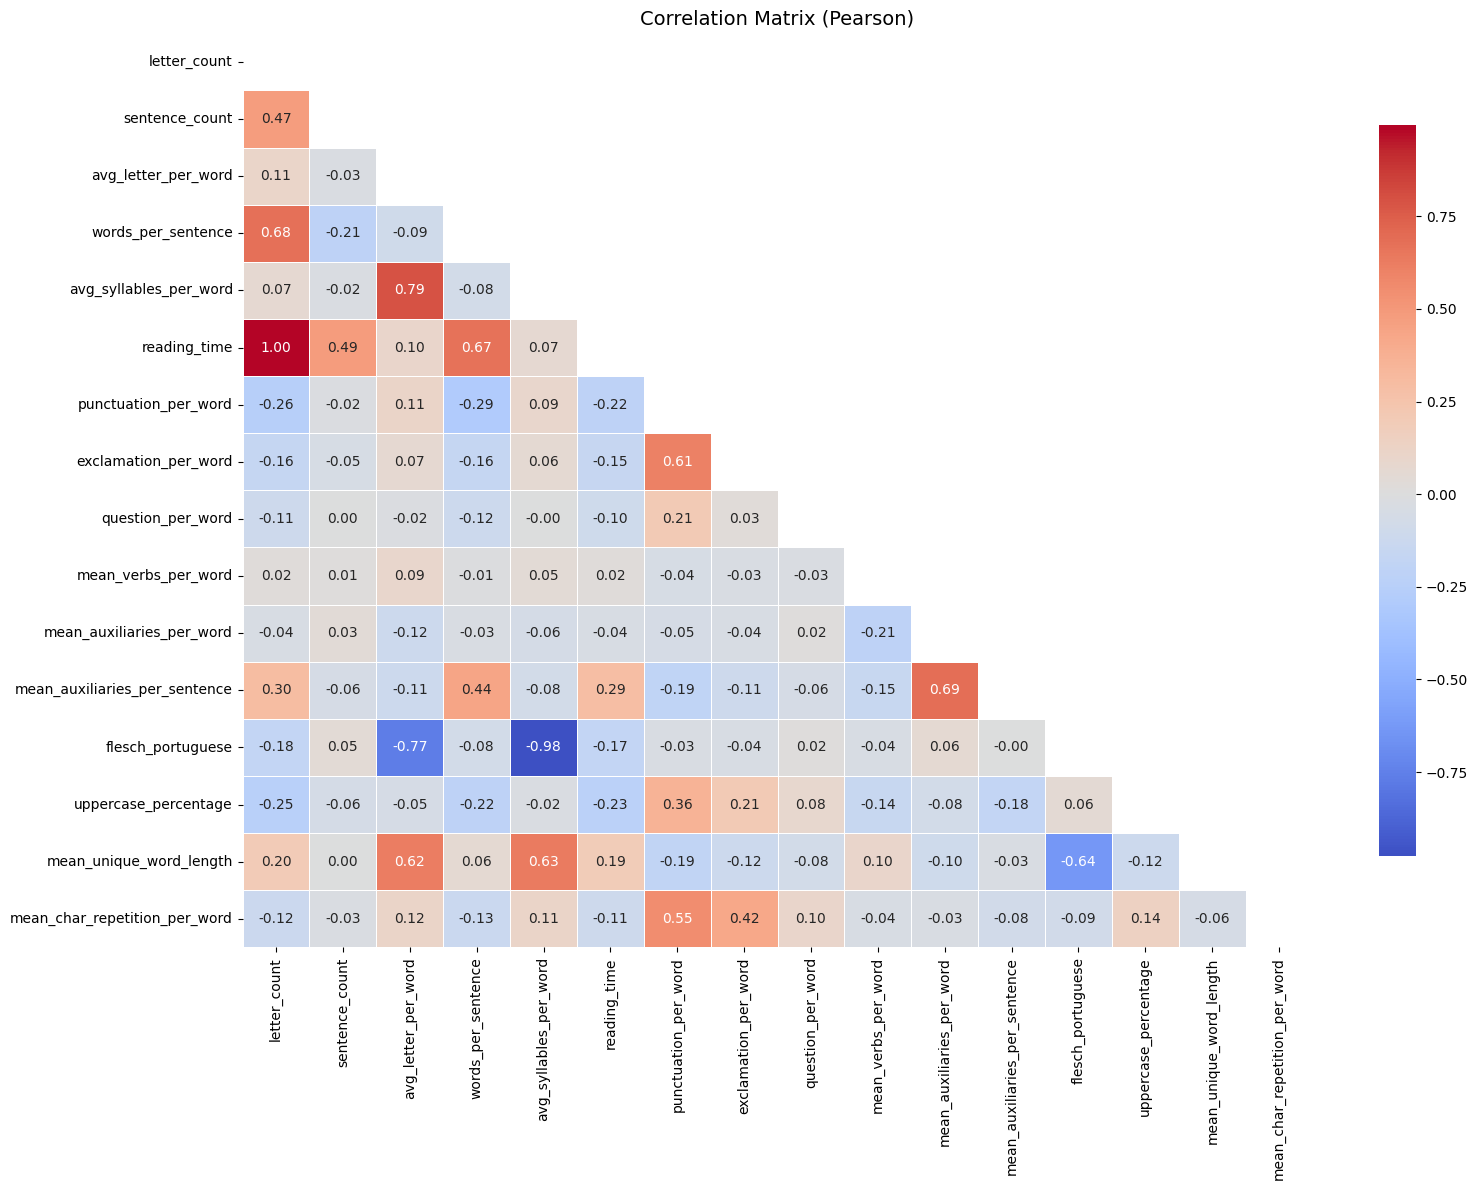

In [15]:
emotion_cols = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

num_cols = df.select_dtypes(include="number")
num_cols = [col for col in num_cols if col not in emotion_cols]
df_num = df[num_cols]
corr = df_num.corr(method="pearson")

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix (Pearson)", fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
df.columns

Index(['id', 'admiration', 'amusement', 'anger', 'annoyance', 'approval',
       'caring', 'confusion', 'curiosity', 'desire', 'disappointment',
       'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear',
       'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride',
       'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral',
       'text', 'texto', 'UNCLEAN_TEXT_PT', 'BASE_TEXT_PT', 'TEXT_NO_STOP_PT',
       'TEXT_LEMMA_PT', 'CLEAN_TEXT_PT', 'UNCLEAN_TEXT_EN', 'BASE_TEXT_EN',
       'TEXT_NO_STOP_EN', 'TEXT_LEMMA_EN', 'CLEAN_TEXT_EN', 'letter_count',
       'sentence_count', 'avg_letter_per_word', 'words_per_sentence',
       'avg_syllables_per_word', 'reading_time', 'punctuation_per_word',
       'exclamation_per_word', 'question_per_word', 'mean_verbs_per_word',
       'mean_auxiliaries_per_word', 'mean_auxiliaries_per_sentence',
       'flesch_portuguese', 'uppercase_percentage', 'mean_unique_word_length',
       'mean_char_repetition_p

In [19]:
emotion_cols = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

base_cols = ["UNCLEAN_TEXT_PT", "BASE_TEXT_PT"]
remove_cols = ['TEXT_NO_STOP', 'CLEAN_TEXT', 'TEXT_LEMMA', 'texto']

feature_cols = [c for c in df.columns if c not in base_cols and c not in remove_cols and c not in emotion_cols]

df_final = df[base_cols + emotion_cols + feature_cols]

df_final.columns

Index(['UNCLEAN_TEXT_PT', 'BASE_TEXT_PT', 'admiration', 'amusement', 'anger',
       'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire',
       'disappointment', 'disapproval', 'disgust', 'embarrassment',
       'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
       'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse',
       'sadness', 'surprise', 'neutral', 'id', 'text', 'TEXT_NO_STOP_PT',
       'TEXT_LEMMA_PT', 'CLEAN_TEXT_PT', 'UNCLEAN_TEXT_EN', 'BASE_TEXT_EN',
       'TEXT_NO_STOP_EN', 'TEXT_LEMMA_EN', 'CLEAN_TEXT_EN', 'letter_count',
       'sentence_count', 'avg_letter_per_word', 'words_per_sentence',
       'avg_syllables_per_word', 'reading_time', 'punctuation_per_word',
       'exclamation_per_word', 'question_per_word', 'mean_verbs_per_word',
       'mean_auxiliaries_per_word', 'mean_auxiliaries_per_sentence',
       'flesch_portuguese', 'uppercase_percentage', 'mean_unique_word_length',
       'mean_char_repetition_per_word']

In [20]:
df_final.to_csv(
    "../data/feat/go_emotions_with_features.csv",
    index=False
)